# Installs

In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip install "terratorch>=1.2.4"
# !pip install "diffusers==0.30.0"
print("\n\n done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 592.7/592.7 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



 done


In [ ]:
# from terratorch.models import TerraMindModel
# m = TerraMindModel.from_pretrained('ibm-esa-geospatial/TerraMind-1.0-small')
# print('OK, params:', sum(p.numel() for p in m.parameters())/1e6, 'M')

# from teratorch import

In [ ]:
!pip install terratorch==1.0.1 gdown tensorboard

#Imports

In [ ]:
import os
import torch
import gdown
import terratorch
import albumentations
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from terratorch.tasks import SemanticSegmentationTask
import gc

# Free any cached memory before training
gc.collect()
torch.cuda.empty_cache()
# from terratorch.datamodules import GenericNonGeoSegment

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


#TEMP

In [ ]:
!rm -rf /content/sen1floods11/

In [ ]:
# Create a folder
!mkdir -p /content/sen1floods11/
# Copy the dataset from the public bucket
!gsutil -m cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia* /content/sen1floods11/
# !gsutil -m cp -r gs://sen1floods11/v1.1/data/ /content/drive/MyDrive/418-Hackathon


Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_233925_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_195474_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_242570_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_294583_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1

In [ ]:
# if not os.path.isfile("sen1floods11_v1.1.tar.gz"):
#     gdown.download("https://drive.google.com/uc?id=118w3X7oFNq_Wyz806uyUJ1jyTuY23VS")
#     !tar -xzvf sen1floods11_v1.1.tar.gz

In [ ]:
dataset_path = Path("sen1floods11_v1.1")
!ls "sen1floods11_v1.1/data"

In [ ]:
!ls "sen1floods11_v1.1/data/S2L1CHand/" | head

#CODE - PRITHVI

#### Downloading the Dataset

In [ ]:
# !rm -rf sen1floods11_custom/

In [ ]:
# 1. Create the necessary directory structure
!mkdir -p sen1floods11_custom/data/S1Hand
!mkdir -p sen1floods11_custom/data/LabelHand
!mkdir -p sen1floods11_custom/splits

In [ ]:
print("Downloading S1 Radar data...")
!gsutil -q -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand sen1floods11_custom/data/S1Hand

# 3. Download ONLY the hand-labeled Ground Truth masks
print("Downloading Label masks...")
!gsutil -q -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand sen1floods11_custom/data/LabelHand

# 4. Download the official Train/Val/Test Split CSVs
print("Downloading split CSVs...")
!gsutil -q -m cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv sen1floods11_custom/splits/
!gsutil -q -m cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv sen1floods11_custom/splits/
!gsutil -q -m cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv sen1floods11_custom/splits/

print("Data successfully downloaded and isolated!")


both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".


both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Data successfully downloaded and isolated!


## Rename Dataset files to work

In [ ]:
# Run this new cell to strip the suffixes from your files and clean the CSVs.

import glob

print("Standardizing filenames and split CSVs...")

# 1. Strip the suffixes from the radar images
for f in glob.glob("sen1floods11_custom/data/S1Hand/*_S1Hand.tif"):
    os.rename(f, f.replace("_S1Hand.tif", ".tif"))

# 2. Strip the suffixes from the label masks
for f in glob.glob("sen1floods11_custom/data/LabelHand/*_LabelHand.tif"):
    os.rename(f, f.replace("_LabelHand.tif", ".tif"))

# 3. Clean the CSV splits so they only contain the base identifier
splits = ["flood_train_data.csv", "flood_valid_data.csv", "flood_test_data.csv"]
for split_csv in splits:
    path = f"sen1floods11_custom/splits/{split_csv}"
    if os.path.exists(path):
        df = pd.read_csv(path, header=None)
        # Extract the base name (strips out any directory paths and suffixes)
        df[0] = df[0].apply(lambda x: str(x).split('/')[-1].replace('_S1Hand.tif', '').replace('.tif', ''))
        # Save only the clean identifier column
        df[[0]].to_csv(path, index=False, header=False)

print("Data standardized! Image and Label stems are now perfectly identical.")

Standardizing filenames and split CSVs...
Data standardized! Image and Label stems are now perfectly identical.


## Model Definition

In [ ]:
# ── Model Architecture ────────────────────────────────────────────────────────

# PRITHVI

# model_args = {
#     # Current
#     "backbone": "prithvi_eo_v1_100",      # 100M params
#     # "backbone": "prithvi_eo_v2_300",    # 300M params, trained on more data
#     # "backbone": "prithvi_eo_v2_600",    # 600M params, best quality, needs more VRAM

#     # "decoder": "FCNDecoder",        # simpler, faster
#     "decoder": "UperNetDecoder",    # (BASIC) current (better for dense prediction)
#     # "decoder": "SegformerDecoder",  # transformer-based, strong on satellite imagery
#     # "decoder": "UNetDecoder",       # (Could try for teramind) good general purpose
#     # "decoder": "SegformerDecoder",  # transformer-based, better at multi-scale features
#     # "decoder": "FPNDecoder",        # (NOT WORKING) Feature Pyramid Network, known for boundary sharpness

#     "backbone_pretrained": True,
#     "backbone_bands": [0, 1], # VV, VH (Sentinel-1 polarizations)
#     "backbone_in_channels": 2,

#     "num_classes": 2,                  # 0: No Flood, 1: Flood
# }

# TERAMIND

# ── Model Architecture ────────────────────────────────────────────────────────
# model_args = {
#     "backbone": "terramind_v1_small",
#     "decoder": "UperNetDecoder",
#     "backbone_pretrained": True,

#     "backbone_modalities": ["S1GRD"],
#     "backbone_bands": {
#         "S1GRD": ["VV", "VH"]
#     },

#     # ── The ViT-to-UperNet Bridge ──
#     "necks": [
#         {
#             "name": "SelectIndices",
#             "indices": [2, 5, 8, 11]  # Extract features from layers 3, 6, 9, and 12 of the transformer
#         },
#         {
#             "name": "ReshapeTokensToImage",
#             "remove_cls_token": False # TerraMind is trained without a CLS token
#         },
#         {
#             "name": "LearnedInterpolateToPyramidal" # Converts single-scale ViT outputs into multi-scale feature maps
#         }
#     ],

#     "num_classes": 2,
# }

# ── Task Configuration ────────────────────────────────────────────────────────
task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,

    # loss="ce", # Cross-Entropy loss
    # loss="focal", # RECOMMENDED: fixes class imbalance (was "ce")
    loss={"ce": 0.5, "dice": 0.5}, # optimize for both pixel accuracy and IoU simultaneously

    # lr=1e-4, # Learning Rate
    lr=6e-5,              # EXPERIMENTAL: slower but more stable convergence
    # lr=2e-4,              # EXPERIMENTAL: faster convergence, risk of overshooting

    scheduler="CosineAnnealingLR",
    scheduler_hparams={"T_max": 75, "eta_min": 1e-6},

    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05,
                       # "weight_decay": 0.01, # EXPERIMENTAL: less regularization, try if underfitting
                       },
    ignore_index=-1,                   # Ignores unlabeled pixels during loss computation
    plot_on_val=False,                 # Disable RGB visualization (incompatible with 2-band input)
)

# trainer.fit(model=task, datamodule=datamodule)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Trainer Config

In [ ]:
# ── Trainer Configuration ─────────────────────────────────────────────────────

# Saves the best model checkpoint based on validation loss
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",
    filename="prithvi-sar-flood-{epoch:02d}-{val/mIoU:.2f}",
    monitor="val/mIoU",     # RECOMMENDED: track mIoU instead of loss (more meaningful for segmentation)
    mode="max",             # RECOMMENDED: changed to max since higher mIoU = better
    save_top_k=1,
)

# Stops training early if val/mIoU stops improving
early_stop_callback = EarlyStopping(
    monitor="val/mIoU",     # RECOMMENDED: match checkpoint monitor
    patience=12,             # RECOMMENDED: bumped from 5 (gives model more time to recover)
    # patience=8,             # RECOMMENDED: bumped from 5 (gives model more time to recover)
    # patience=5,           # original — fine if you want faster runs
    mode="max",
    verbose=True,
)

trainer = pl.Trainer(
    # max_epochs=100,          # focal loss needs more time
    # max_epochs=75,          # focal loss needs more time
    max_epochs=50,          # RECOMMENDED: bumped from 25, use early stopping as the real cutoff
    # max_epochs=25,        # original — fine for a quick test run
    accelerator="gpu",
    devices=1,
    precision="16-mixed",   # ~2x speedup, cuts VRAM usage significantly
    accumulate_grad_batches=2,  # RECOMMENDED SPEEDUP: simulates batch_size=16 without extra VRAM
    num_sanity_val_steps=0,     # SPEEDUP: skips pre-training sanity check
    log_every_n_steps=5,
    check_val_every_n_epoch=2,          # keep
    callbacks=[checkpoint_callback, early_stop_callback],
)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
# print("Configuring PyTorch Lightning Trainer...")

# # Save the best model based on validation loss
# checkpoint_callback = ModelCheckpoint(
#     dirpath="checkpoints/",
#     filename="prithvi-sar-flood-{epoch:02d}-{val/loss:.2f}",
#     monitor="val/loss",
#     mode="min",
#     save_top_k=1,
# )

# # Prevent overfitting by stopping early if validation loss plateaus
# early_stop_callback = EarlyStopping(
#     monitor="val/loss",
#     patience=5,
#     mode="min",
#     verbose=True
# )

# # Set up Trainer for Colab GPU execution
# trainer = pl.Trainer(
#     max_epochs=25,                    # Good baseline duration
#     accelerator="gpu",                # Automatically utilizes Colab's T4/A100 GPU
#     devices=1,
#     callbacks=[checkpoint_callback, early_stop_callback],
#     log_every_n_steps=10,
#     precision="16-mixed"              # Memory optimization: speeds up training on Colab
# )

# print("Starting Baseline Training Loop...")

# # Assuming your DataModule is stored in the variable `datamodule`
# # Execute the fine-tuning loop:
# trainer.fit(model=task, datamodule=datamodule)

## Initializing DataModule

In [ ]:
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
torch.backends.cudnn.benchmark = True # Enable CUDNN benchmark — speeds up fixed-size inputs

print("\nInitializing DataModule...\n")

# Instantiate the DataModule with our cleaned data
datamodule = GenericNonGeoSegmentationDataModule(
    # batch_size=8, # 8 images fed to the model per forward pass
    # num_workers=2, # 2 CPU threads load data in parallel while GPU trains (prevents bottleneck)
    # num_workers=4, # Colab T4 only has 2 usable CPU workers so 4 is a sweet spot(WAY SLOWER)

    batch_size=16, # T4 15GB can comfortably handle 16 with fp16 (was 8)
    num_workers=0, # Colab T4 only has 2 usable CPU workers
    # num_workers=2, # Colab T4 only has 2 usable CPU workers
    pin_memory=True, # Faster CPU→GPU transfer on Colab
    # persistent_workers=True, # workers stay alive between epochs
    dataset_bands=[1, 2], # (Sentinel-1 has VV and VH polarization)

    num_classes=2, # binary classification

    train_data_root="sen1floods11_custom/data/S1Hand",
    train_label_data_root="sen1floods11_custom/data/LabelHand",

    val_data_root="sen1floods11_custom/data/S1Hand",
    val_label_data_root="sen1floods11_custom/data/LabelHand",

    test_data_root="sen1floods11_custom/data/S1Hand",
    test_label_data_root="sen1floods11_custom/data/LabelHand",

    train_split="sen1floods11_custom/splits/flood_train_data.csv",
    val_split="sen1floods11_custom/splits/flood_valid_data.csv",
    test_split="sen1floods11_custom/splits/flood_test_data.csv",

    # Since the files are identically named, standard globbing works natively
    img_grep="*.tif",
    label_grep="*.tif",

    no_data_replace=0,
    no_label_replace=-1,

    # train_transform=[
    #       {"class_path": "albumentations.HorizontalFlip", "init_args": {"p": 0.5}},
    #       {"class_path": "albumentations.VerticalFlip", "init_args": {"p": 0.5}},
    #       {"class_path": "albumentations.RandomRotate90", "init_args": {"p": 0.5}},
    #       {"class_path": "albumentations.pytorch.transforms.ToTensorV2"},  # ← fixes the numpy → tensor issue
    # ],

    # train_transform=[
    #     {"class_path": "albumentations.HorizontalFlip", "init_args": {"p": 0.5}},
    #     {"class_path": "albumentations.VerticalFlip", "init_args": {"p": 0.5}},
    #     {"class_path": "albumentations.RandomRotate90", "init_args": {"p": 0.5}},
    #     {"class_path": "albumentations.GaussianBlur", "init_args": {"p": 0.2}},
    #     {"class_path": "albumentations.RandomBrightnessContrast", "init_args": {"p": 0.3}},
    #     {"class_path": "albumentations.pytorch.transforms.ToTensorV2"},  # ← fixes the numpy → tensor issue
    # ],

    # No augmentations for val/test — evaluate on clean data
    # val_transform=None,
    # test_transform=None,
)

datamodule.setup(stage="fit")

print("Initialized DataModule...\n")


Initializing DataModule...

Initialized DataModule...



## Compile and Fit

In [ ]:
# Compile model for ~25% speedup (PyTorch 2.0+)
# task.model = torch.compile(task.model)

print("\nDataModule ready! Starting fine-tuning...\n")
trainer.fit(model=task, datamodule=datamodule)


DataModule ready! Starting fine-tuning...



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │ 30.1 M │ train │     0 │
│ 1 │ criterion     │ CombinedLoss     │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 30.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.1 M                                                                                               
Total estimated model params size (MB): 120                                                                        
Modules in train mode: 295                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


## Evaluating model on the unseen test dataset

In [ ]:
print("\nEvaluating model on the unseen test dataset...\n")

# By passing ckpt_path="best", PyTorch Lightning automatically loads the
# weights from your 0.141 val/loss epoch, ignoring the later overfitting epochs!
trainer.test(model=task, datamodule=datamodule, ckpt_path="best")

INFO: Restoring states from the checkpoint path at /content/checkpoints/prithvi-sar-flood-epoch=43-val/mIoU=0.79.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/prithvi-sar-flood-epoch=43-val/mIoU=0.79.ckpt



Evaluating model on the unseen test dataset...



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/checkpoints/prithvi-sar-flood-epoch=43-val/mIoU=0.79.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/prithvi-sar-flood-epoch=43-val/mIoU=0.79.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │     0.852307140827179     │
│    test/Boundary_mIoU     │    0.10520066320896149    │
│   test/Class_Accuracy_0   │    0.9771896600723267     │
│   test/Class_Accuracy_1   │    0.7274246215820312     │
│       test/F1_Score       │    0.8701738119125366     │
│        test/IoU_0         │    0.9405423402786255     │
│        test/IoU_1         │    0.6273224353790283     │
│    test/Pixel_Accuracy    │     0.945951521396637     │
│       test/ce_epoch       │    0.1935473382472992     │
│      test/dice_epoch      │    0.18176867067813873    │
│         test/loss         │    0.18765801191329956    │
│         test/mIoU         │    0.7839323878288269     │
│      test/mIoU_Micro      │    0.8974461555480957     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.18765801191329956,
  'test/ce_epoch': 0.1935473382472992,
  'test/dice_epoch': 0.18176867067813873,
  'test/Accuracy': 0.852307140827179,
  'test/Boundary_mIoU': 0.10520066320896149,
  'test/Class_Accuracy_0': 0.9771896600723267,
  'test/Class_Accuracy_1': 0.7274246215820312,
  'test/F1_Score': 0.8701738119125366,
  'test/IoU_0': 0.9405423402786255,
  'test/IoU_1': 0.6273224353790283,
  'test/Pixel_Accuracy': 0.945951521396637,
  'test/mIoU': 0.7839323878288269,
  'test/mIoU_Micro': 0.8974461555480957}]

## Finds non-dry files

In [ ]:
import glob
import rasterio
import numpy as np

print("Scanning local dataset for significantly flooded images...")

# Grab all the label masks
label_files = glob.glob("/content/sen1floods11_custom/data/LabelHand/*.tif")
flooded_files = []

# Check each one for water
for path in label_files:
    with rasterio.open(path) as src:
        mask = src.read(1)
        water_pixels = np.sum(mask == 1)

        # If it has a decent amount of water (e.g., > 10,000 pixels), save it
        if water_pixels > 10000:
            # Convert the label path back to the S1 radar path so you can use it in inference
            s1_path = path.replace("LabelHand", "S1Hand")
            flooded_files.append((water_pixels, s1_path))

# Sort them from most water to least water
flooded_files.sort(reverse=True)

print("-" * 50)
print("🎯 GUARANTEED FLOODED TEST IMAGES FOUND 🎯")
print("-" * 50)

# Print the top 5 best ones to test
for pixels, s1_path in flooded_files[:5]:
    area_km2 = (pixels * 100) / 1_000_000
    print(f"Path: {s1_path}")
    print(f"      Water Pixels: {pixels} (~{area_km2:.2f} km²)")
    print()

Scanning local dataset for significantly flooded images...
--------------------------------------------------
🎯 GUARANTEED FLOODED TEST IMAGES FOUND 🎯
--------------------------------------------------
Path: /content/sen1floods11_custom/data/S1Hand/Sri-Lanka_534068.tif
      Water Pixels: 257268 (~25.73 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Sri-Lanka_845821.tif
      Water Pixels: 234546 (~23.45 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Nigeria_529525.tif
      Water Pixels: 223651 (~22.37 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Nigeria_984831.tif
      Water Pixels: 221680 (~22.17 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Mekong_52610.tif
      Water Pixels: 210673 (~21.07 km²)



## Visualize a raw .tif

Initializing Advanced Inference Engine...
Running inference on: /content/sen1floods11_custom/data/S1Hand/Sri-Lanka_534068.tif
----------------------------------------
🚨 DISASTER ASSESSMENT REPORT 🚨
ACTUAL Ground Truth Pixels:  257268
MODEL Predicted Pixels:      262144
Estimated Affected Area:     26.214 km²
----------------------------------------


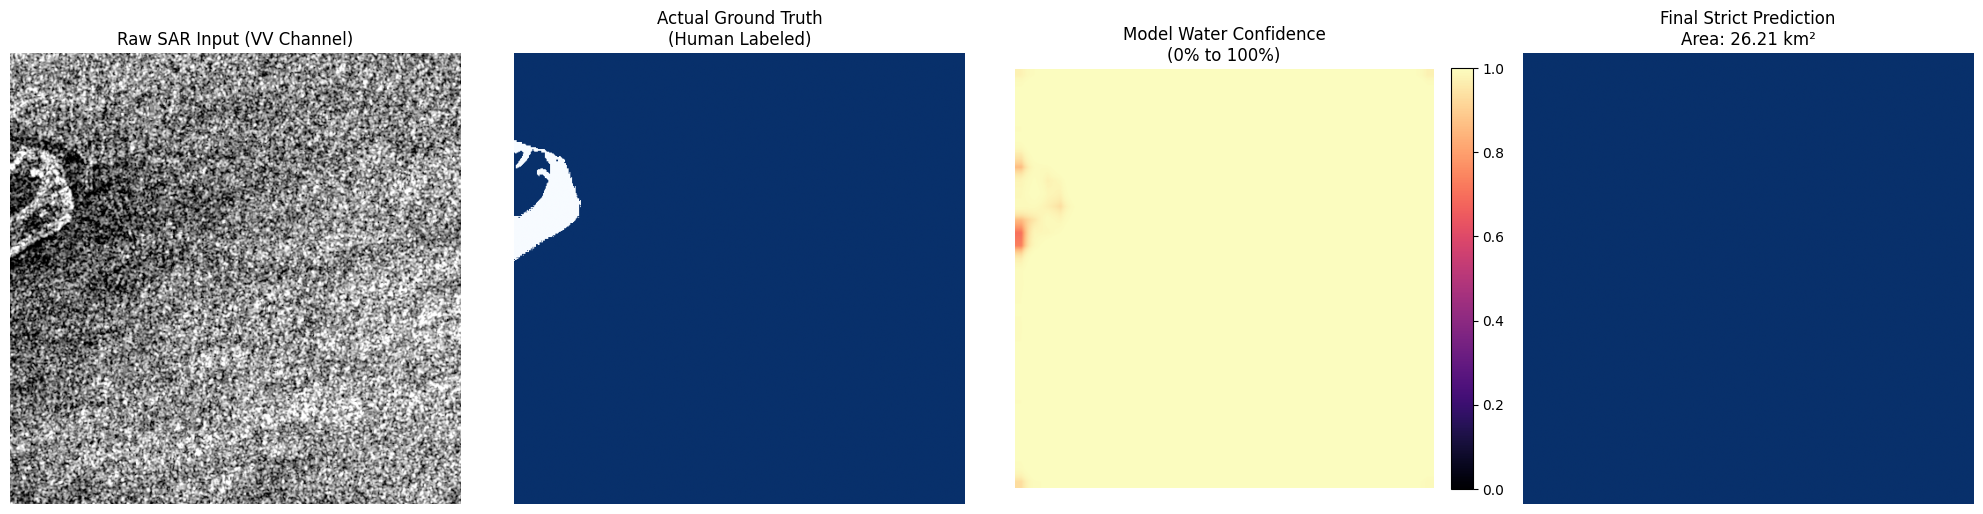

In [ ]:
import os
import torch
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

print("Initializing Advanced Inference Engine...")

# 1. Put your loaded model into evaluation mode
task.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
task.to(device)

# 2. Pick a test image
test_image_path = "/content/sen1floods11_custom/data/S1Hand/Sri-Lanka_534068.tif"
# test_image_path = "/content/sen1floods11_custom/data/S1Hand/Bolivia_129334.tif"
print(f"Running inference on: {test_image_path}")

# 3. Load the 2-channel SAR image
with rasterio.open(test_image_path) as src:
    img_array = src.read([1, 2])

# 4. Preprocess: Convert to tensor, add batch dimension [B, C, H, W], move to GPU
input_tensor = torch.tensor(img_array, dtype=torch.float32).unsqueeze(0).to(device)

# 5. Run the Forward Pass
with torch.no_grad():
    model_output = task(input_tensor)

    # Extract the raw tensor
    if hasattr(model_output, 'output'):
        logits = model_output.output
    elif hasattr(model_output, 'logits'):
        logits = model_output.logits
    elif isinstance(model_output, dict):
        logits = model_output.get('out', model_output.get('logits'))
    else:
        logits = model_output

    # THE UPGRADE: Calculate raw probabilities instead of just the strict argmax
    probabilities = F.softmax(logits, dim=1)

    # Extract the probability map strictly for Class 1 (Flood)
    water_prob_map = probabilities[0, 1, :, :].cpu().numpy()

    # Calculate the strict binary mask (> 50% confidence)
    prediction_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

# 6. Auto-Load Ground Truth (if it exists)
label_path = test_image_path.replace("S1Hand", "LabelHand")
true_flood_pixels = "N/A"
if os.path.exists(label_path):
    with rasterio.open(label_path) as src:
        true_mask = src.read(1)
        true_flood_pixels = np.sum(true_mask == 1)

# 7. Calculate the Disaster Impact Area
flood_pixels = np.sum(prediction_mask == 1)
sq_meters_per_pixel = 100
flood_area_km2 = flood_pixels * sq_meters_per_pixel / 1_000_000

print("-" * 40)
print("🚨 DISASTER ASSESSMENT REPORT 🚨")
print(f"ACTUAL Ground Truth Pixels:  {true_flood_pixels}")
print(f"MODEL Predicted Pixels:      {flood_pixels}")
print(f"Estimated Affected Area:     {flood_area_km2:.3f} km²")
print("-" * 40)

# 8. Advanced Visualization
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# Plot 1: Raw SAR (using percentile clipping to handle radar glare/outliers)
vmin, vmax = np.percentile(img_array[0], (2, 98))
ax[0].imshow(img_array[0], cmap='gray', vmin=vmin, vmax=vmax)
ax[0].set_title("Raw SAR Input (VV Channel)")
ax[0].axis('off')

# Plot 2: Ground Truth
if os.path.exists(label_path):
    # Mask out the -1 nodata values so they don't mess up the colors
    display_true_mask = np.ma.masked_where(true_mask == -1, true_mask)
    ax[1].imshow(display_true_mask, cmap='Blues', vmin=0, vmax=1)
ax[1].set_title("Actual Ground Truth\n(Human Labeled)")
ax[1].axis('off')

# Plot 3: Model Confidence (The "X-Ray")
im = ax[2].imshow(water_prob_map, cmap='magma', vmin=0, vmax=1)
ax[2].set_title("Model Water Confidence\n(0% to 100%)")
ax[2].axis('off')
fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

# Plot 4: Final Binary Mask
ax[3].imshow(prediction_mask, cmap='Blues', vmin=0, vmax=1)
ax[3].set_title(f"Final Strict Prediction\nArea: {flood_area_km2:.2f} km²")
ax[3].axis('off')

plt.tight_layout()
plt.show()

###TEMP 2

In [ ]:
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

dataset_path = Path("sen1floods11_v1.1")
s1_images_dir = dataset_path / "data" / "S1Hand"
labels_dir = dataset_path / "data" / "LabelHand"

# Initialize the DataModule strictly for Sentinel-1 SAR
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=8,
    num_workers=2,

    # We are predicting 2 classes: 0 (No Water) and 1 (Water)
    num_classes=2,

    # 1. Point to the Radar data and Hand-labeled data ONLY
    train_data_root=s1_images_dir,
    train_label_data_root=labels_dir,
    val_data_root=s1_images_dir,
    val_label_data_root=labels_dir,

    # 2. Tell the model to expect 2-channel radar input (VV, VH) instead of optical
    dataset_bands=["VV", "VH"],
    output_bands=["VV", "VH"],

    # 3. Handle the dataset splits
    # If you have text files containing the names of your train/val chips
    # (just like the Bolivia test split we made earlier), link them here:
    # train_split=dataset_path / "v1.1_splits" / "flood_handlabeled_train.csv",
    # val_split=dataset_path / "v1.1_splits" / "flood_handlabeled_valid.csv",
)

# Setup the datamodule for training
datamodule.setup("fit")

# Verify it loaded correctly
train_loader = datamodule.train_dataloader()
batch = next(iter(train_loader))

print("Successfully loaded SAR data!")
print(f"Image batch shape: {batch['image'].shape}") # Should be [8, 2, 512, 512] (Batch, Channels, H, W)
print(f"Label batch shape: {batch['mask'].shape}")  # Should be [8, 1, 512, 512]

#CODE - TERAMIND

#### Downloading the Dataset

In [ ]:
# !rm -rf sen1floods11_custom/

In [ ]:
# 1. Create the necessary directory structure
!mkdir -p sen1floods11_custom/data/S1Hand
!mkdir -p sen1floods11_custom/data/LabelHand
!mkdir -p sen1floods11_custom/splits

In [ ]:
print("Downloading S1 Radar data...")
!gsutil -q -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand sen1floods11_custom/data/S1Hand

# 3. Download ONLY the hand-labeled Ground Truth masks
print("Downloading Label masks...")
!gsutil -q -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand sen1floods11_custom/data/LabelHand

# 4. Download the official Train/Val/Test Split CSVs
print("Downloading split CSVs...")
!gsutil -q -m cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv sen1floods11_custom/splits/
!gsutil -q -m cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv sen1floods11_custom/splits/
!gsutil -q -m cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv sen1floods11_custom/splits/

print("Data successfully downloaded and isolated!")


both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".


both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Data successfully downloaded and isolated!


## Rename Dataset files to work

In [ ]:
# Run this new cell to strip the suffixes from your files and clean the CSVs.

import glob

print("Standardizing filenames and split CSVs...")

# 1. Strip the suffixes from the radar images
for f in glob.glob("sen1floods11_custom/data/S1Hand/*_S1Hand.tif"):
    os.rename(f, f.replace("_S1Hand.tif", ".tif"))

# 2. Strip the suffixes from the label masks
for f in glob.glob("sen1floods11_custom/data/LabelHand/*_LabelHand.tif"):
    os.rename(f, f.replace("_LabelHand.tif", ".tif"))

# 3. Clean the CSV splits so they only contain the base identifier
splits = ["flood_train_data.csv", "flood_valid_data.csv", "flood_test_data.csv"]
for split_csv in splits:
    path = f"sen1floods11_custom/splits/{split_csv}"
    if os.path.exists(path):
        df = pd.read_csv(path, header=None)
        # Extract the base name (strips out any directory paths and suffixes)
        df[0] = df[0].apply(lambda x: str(x).split('/')[-1].replace('_S1Hand.tif', '').replace('.tif', ''))
        # Save only the clean identifier column
        df[[0]].to_csv(path, index=False, header=False)

print("Data standardized! Image and Label stems are now perfectly identical.")

Standardizing filenames and split CSVs...
Data standardized! Image and Label stems are now perfectly identical.


## Model Definition

In [ ]:
# TERAMIND

# ── Model Architecture ────────────────────────────────────────────────────────
model_args = {
    "backbone": "terramind_v1_tiny",
    "decoder": "UperNetDecoder",
    "backbone_pretrained": True,

    "backbone_modalities": ["S1GRD"],
    "backbone_bands": {
        "S1GRD": ["VV", "VH"]
    },

    # ── The ViT-to-UperNet Bridge ──
    "necks": [
        {
            "name": "SelectIndices",
            "indices": [2, 5, 8, 11]  # Extract features from layers 3, 6, 9, and 12 of the transformer
        },
        {
            "name": "ReshapeTokensToImage",
            "remove_cls_token": False # TerraMind is trained without a CLS token
        },
        {
            "name": "LearnedInterpolateToPyramidal" # Converts single-scale ViT outputs into multi-scale feature maps
        }
    ],

    "num_classes": 2,
}

# ── Task Configuration ────────────────────────────────────────────────────────
task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,

    # loss="ce", # Cross-Entropy loss
    # loss="focal", # RECOMMENDED: fixes class imbalance (was "ce")
    loss={"ce": 0.5, "dice": 0.5}, # optimize for both pixel accuracy and IoU simultaneously

    # lr=1e-4, # Learning Rate
    lr=6e-5,              # EXPERIMENTAL: slower but more stable convergence
    # lr=2e-4,              # EXPERIMENTAL: faster convergence, risk of overshooting

    scheduler="CosineAnnealingLR",
    scheduler_hparams={"T_max": 50, "eta_min": 1e-6},  # match max_epochs
    # scheduler_hparams={"T_max": 75, "eta_min": 1e-6},

    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05,
                       # "weight_decay": 0.01, # EXPERIMENTAL: less regularization, try if underfitting
                       },
    ignore_index=-1,                   # Ignores unlabeled pixels during loss computation
    plot_on_val=False,                 # Disable RGB visualization (incompatible with 2-band input)
)

# trainer.fit(model=task, datamodule=datamodule)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


TerraMind_v1_tiny.pt:   0%|          | 0.00/212M [00:00<?, ?B/s]

## Trainer Config

In [ ]:
# ── Trainer Configuration ─────────────────────────────────────────────────────

# Saves the best model checkpoint based on validation loss
# checkpoint_callback = ModelCheckpoint(
#     dirpath="checkpoints/",
#     filename="terramind-sar-flood-{epoch:02d}-{val_mIoU:.2f}",
#     monitor="val/mIoU",
#     mode="max",
#     save_top_k=1,
# )
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",
    # ── THE FIX: Use the exact key with the slash ──
    filename="terramind-sar-final-best",
    # filename="terramind-sar-flood-{epoch:02d}-{val/mIoU:.2f}",
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
)

# Stops training early if val/mIoU stops improving
early_stop_callback = EarlyStopping(
    monitor="val/mIoU",     # RECOMMENDED: match checkpoint monitor
    patience=12,             # RECOMMENDED: bumped from 5 (gives model more time to recover)
    # patience=8,             # RECOMMENDED: bumped from 5 (gives model more time to recover)
    # patience=5,           # original — fine if you want faster runs
    mode="max",
    verbose=True,
)

trainer = pl.Trainer(
    # max_epochs=100,          # focal loss needs more time
    # max_epochs=75,          # focal loss needs more time
    max_epochs=50,          # RECOMMENDED: bumped from 25, use early stopping as the real cutoff
    # max_epochs=25,        # original — fine for a quick test run
    accelerator="gpu",
    devices=1,
    precision="16-mixed",   # ~2x speedup, cuts VRAM usage significantly
    accumulate_grad_batches=2,  # RECOMMENDED SPEEDUP: simulates batch_size=16 without extra VRAM
    num_sanity_val_steps=2,     # SPEEDUP: skips pre-training sanity check
    # num_sanity_val_steps=0,     # SPEEDUP: skips pre-training sanity check
    log_every_n_steps=5,
    check_val_every_n_epoch=2,          # keep
    callbacks=[checkpoint_callback, early_stop_callback],
)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Initializing DataModule

In [ ]:
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
torch.backends.cudnn.benchmark = True # Enable CUDNN benchmark — speeds up fixed-size inputs

print("\nInitializing DataModule...\n")

# Instantiate the DataModule with our cleaned data
datamodule = GenericNonGeoSegmentationDataModule(
    # batch_size=8, # 8 images fed to the model per forward pass
    # num_workers=2, # 2 CPU threads load data in parallel while GPU trains (prevents bottleneck)
    # num_workers=4, # Colab T4 only has 2 usable CPU workers so 4 is a sweet spot(WAY SLOWER)

    batch_size=8, # T4 15GB can comfortably handle 16 with fp16 (was 8)
    # batch_size=16, # T4 15GB can comfortably handle 16 with fp16 (was 8)
    num_workers=0, # Colab T4 only has 2 usable CPU workers
    # num_workers=2, # Colab T4 only has 2 usable CPU workers
    pin_memory=False, # Faster CPU→GPU transfer on Colab
    # pin_memory=True, # Faster CPU→GPU transfer on Colab
    # persistent_workers=True, # workers stay alive between epochs
    dataset_bands=[1, 2], # (Sentinel-1 has VV and VH polarization)
    # dataset_bands=[1, 2], # (Sentinel-1 has VV and VH polarization)

    num_classes=2, # binary classification

    train_data_root="sen1floods11_custom/data/S1Hand",
    train_label_data_root="sen1floods11_custom/data/LabelHand",

    val_data_root="sen1floods11_custom/data/S1Hand",
    val_label_data_root="sen1floods11_custom/data/LabelHand",

    test_data_root="sen1floods11_custom/data/S1Hand",
    test_label_data_root="sen1floods11_custom/data/LabelHand",

    train_split="sen1floods11_custom/splits/flood_train_data.csv",
    val_split="sen1floods11_custom/splits/flood_valid_data.csv",
    test_split="sen1floods11_custom/splits/flood_test_data.csv",

    # Since the files are identically named, standard globbing works natively
    img_grep="*.tif",
    label_grep="*.tif",

    no_data_replace=0,
    no_label_replace=-1,

    # No augmentations for val/test — evaluate on clean data
    # val_transform=None,
    # test_transform=None,
)

datamodule.setup(stage="fit")

print("Initialized DataModule...\n")


Initializing DataModule...

Initialized DataModule...



In [ ]:
datamodule.setup(stage="fit")
train_loader = datamodule.train_dataloader()

print("Testing first batch...")
batch = next(iter(train_loader))

# Let's see exactly what keys TerraTorch gave us
print("Batch loaded! Keys inside batch:", batch.keys())

# Now let's print the shapes using the correct dictionary keys
print("Image shape:", batch["image"].shape)
print("Mask shape:", batch["mask"].shape)

Testing first batch...
Batch loaded! Keys inside batch: dict_keys(['image', 'mask', 'filename'])
Image shape: torch.Size([8, 2, 512, 512])
Mask shape: torch.Size([8, 512, 512])


In [ ]:
task.eval()
task.cuda()

with torch.no_grad():
    dummy = torch.randn(2, 2, 512, 512).cuda()
    print("Running forward pass...")
    out = task.model(dummy)

    # ── THE FIX ──
    # Extract the raw tensor from the ModelOutput wrapper
    if hasattr(out, 'output'):
        logits = out.output
    elif hasattr(out, 'logits'):
        logits = out.logits
    else:
        # Just in case we need to see what's inside
        print("Attributes in ModelOutput:", dir(out))
        logits = out[0] # Fallback

    print("Extracted Logits shape:", logits.shape)

Running forward pass...
Extracted Logits shape: torch.Size([2, 2, 512, 512])


## Compile and Fit

In [ ]:
trainer.fit(model=task, datamodule=datamodule)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │ 12.8 M │ eval │     0 │
│ 1 │ criterion     │ CombinedLoss     │      0 │ eval │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ eval │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ eval │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ eval │     0 │
└───┴───────────────┴──────────────────┴────────┴──────┴───────┘

Trainable params: 12.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 12.8 M                                                                                               
Total estimated model params size (MB): 51                                                                         
Modules in train mode: 0                                                                                           
Modules in eval mode: 295                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


In [ ]:
# Compile model for ~25% speedup (PyTorch 2.0+)
# task.model = torch.compile(task.model)

print("\nDataModule ready! Starting fine-tuning...\n")
trainer.fit(model=task, datamodule=datamodule)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



DataModule ready! Starting fine-tuning...



/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │ 12.8 M │ eval │     0 │
│ 1 │ criterion     │ CombinedLoss     │      0 │ eval │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ eval │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ eval │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ eval │     0 │
└───┴───────────────┴──────────────────┴────────┴──────┴───────┘

Trainable params: 12.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 12.8 M                                                                                               
Total estimated model params size (MB): 51                                                                         
Modules in train mode: 0                                                                                           
Modules in eval mode: 295                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


## Evaluating model on the unseen test dataset

In [ ]:
print("\nEvaluating model on the unseen test dataset...\n")

# By passing ckpt_path="best", PyTorch Lightning automatically loads the
# weights from your 0.141 val/loss epoch, ignoring the later overfitting epochs!
trainer.test(model=task, datamodule=datamodule, ckpt_path="best")

INFO: Restoring states from the checkpoint path at /content/checkpoints/terramind-sar-flood-epoch=27-val/mIoU=0.78.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/terramind-sar-flood-epoch=27-val/mIoU=0.78.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/checkpoints/terramind-sar-flood-epoch=27-val/mIoU=0.78.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/terramind-sar-flood-epoch=27-val/mIoU=0.78.ckpt



Evaluating model on the unseen test dataset...



Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.8625264167785645     │
│    test/Boundary_mIoU     │    0.1367352157831192     │
│   test/Class_Accuracy_0   │    0.9726006984710693     │
│   test/Class_Accuracy_1   │    0.7524520754814148     │
│       test/F1_Score       │    0.8714049458503723     │
│        test/IoU_0         │    0.9393600821495056     │
│        test/IoU_1         │    0.6314250230789185     │
│    test/Pixel_Accuracy    │    0.9450667500495911     │
│       test/ce_epoch       │    0.18126815557479858    │
│      test/dice_epoch      │    0.18195703625679016    │
│         test/loss         │    0.18161261081695557    │
│         test/mIoU         │    0.7853925228118896     │
│      test/mIoU_Micro      │    0.8958545923233032     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.18161261081695557,
  'test/ce_epoch': 0.18126815557479858,
  'test/dice_epoch': 0.18195703625679016,
  'test/Accuracy': 0.8625264167785645,
  'test/Boundary_mIoU': 0.1367352157831192,
  'test/Class_Accuracy_0': 0.9726006984710693,
  'test/Class_Accuracy_1': 0.7524520754814148,
  'test/F1_Score': 0.8714049458503723,
  'test/IoU_0': 0.9393600821495056,
  'test/IoU_1': 0.6314250230789185,
  'test/Pixel_Accuracy': 0.9450667500495911,
  'test/mIoU': 0.7853925228118896,
  'test/mIoU_Micro': 0.8958545923233032}]

## Finds non-dry files

In [ ]:
import glob
import rasterio
import numpy as np

print("Scanning local dataset for significantly flooded images...")

# Grab all the label masks
label_files = glob.glob("/content/sen1floods11_custom/data/LabelHand/*.tif")
flooded_files = []

# Check each one for water
for path in label_files:
    with rasterio.open(path) as src:
        mask = src.read(1)
        water_pixels = np.sum(mask == 1)

        # If it has a decent amount of water (e.g., > 10,000 pixels), save it
        if water_pixels > 10000:
            # Convert the label path back to the S1 radar path so you can use it in inference
            s1_path = path.replace("LabelHand", "S1Hand")
            flooded_files.append((water_pixels, s1_path))

# Sort them from most water to least water
flooded_files.sort(reverse=True)

print("-" * 50)
print("🎯 GUARANTEED FLOODED TEST IMAGES FOUND 🎯")
print("-" * 50)

# Print the top 5 best ones to test
for pixels, s1_path in flooded_files[:5]:
    area_km2 = (pixels * 100) / 1_000_000
    print(f"Path: {s1_path}")
    print(f"      Water Pixels: {pixels} (~{area_km2:.2f} km²)")
    print()

Scanning local dataset for significantly flooded images...
--------------------------------------------------
🎯 GUARANTEED FLOODED TEST IMAGES FOUND 🎯
--------------------------------------------------
Path: /content/sen1floods11_custom/data/S1Hand/Sri-Lanka_534068.tif
      Water Pixels: 257268 (~25.73 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Sri-Lanka_845821.tif
      Water Pixels: 234546 (~23.45 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Nigeria_529525.tif
      Water Pixels: 223651 (~22.37 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Nigeria_984831.tif
      Water Pixels: 221680 (~22.17 km²)

Path: /content/sen1floods11_custom/data/S1Hand/Mekong_52610.tif
      Water Pixels: 210673 (~21.07 km²)



## Visualize a raw .tif

Initializing Advanced Inference Engine...
Running inference on: /content/sen1floods11_custom/data/S1Hand/Sri-Lanka_534068.tif
----------------------------------------
🚨 DISASTER ASSESSMENT REPORT 🚨
ACTUAL Ground Truth Pixels:  257268
MODEL Predicted Pixels:      262144
Estimated Affected Area:     26.214 km²
----------------------------------------


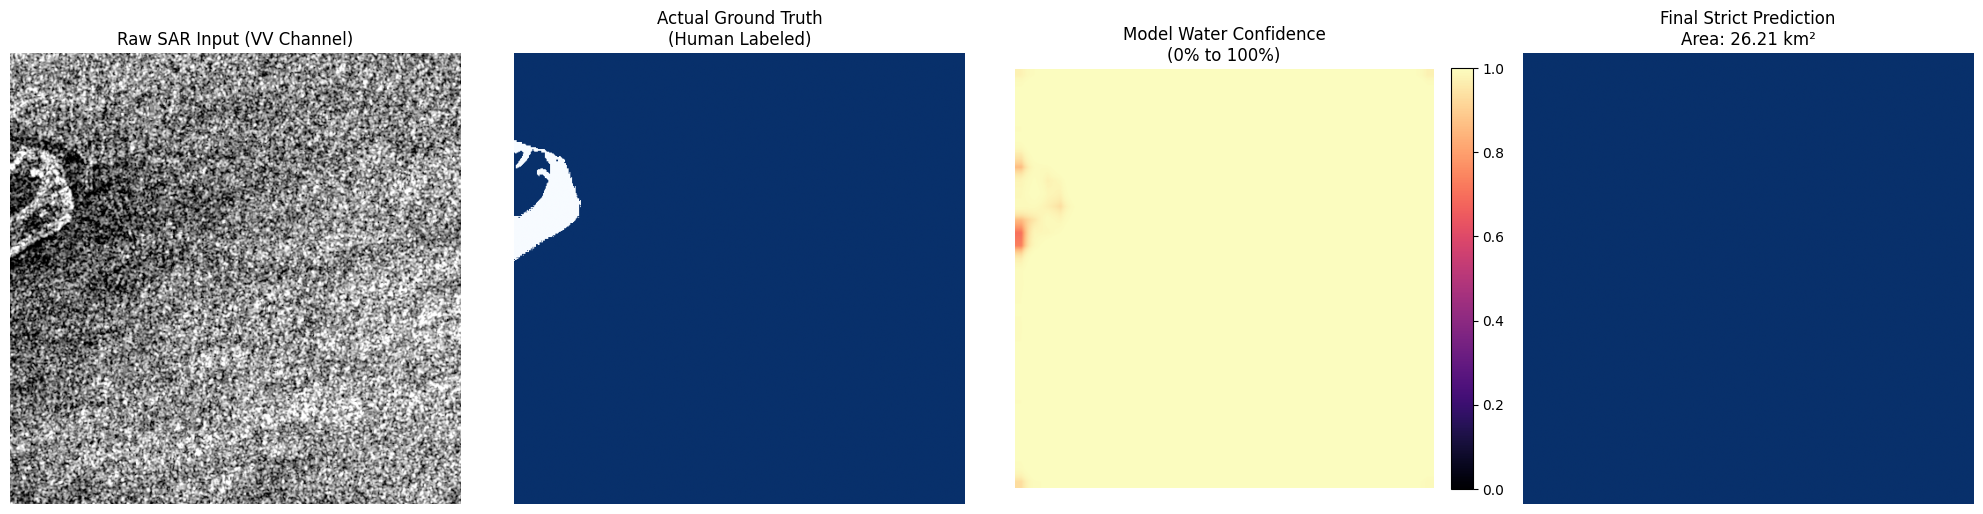

In [ ]:
import os
import torch
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

print("Initializing Advanced Inference Engine...")

# 1. Put your loaded model into evaluation mode
task.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
task.to(device)

# 2. Pick a test image
test_image_path = "/content/sen1floods11_custom/data/S1Hand/Sri-Lanka_534068.tif"
# test_image_path = "/content/sen1floods11_custom/data/S1Hand/Bolivia_129334.tif"
print(f"Running inference on: {test_image_path}")

# 3. Load the 2-channel SAR image
with rasterio.open(test_image_path) as src:
    img_array = src.read([1, 2])

# 4. Preprocess: Convert to tensor, add batch dimension [B, C, H, W], move to GPU
input_tensor = torch.tensor(img_array, dtype=torch.float32).unsqueeze(0).to(device)

# 5. Run the Forward Pass
with torch.no_grad():
    model_output = task(input_tensor)

    # Extract the raw tensor
    if hasattr(model_output, 'output'):
        logits = model_output.output
    elif hasattr(model_output, 'logits'):
        logits = model_output.logits
    elif isinstance(model_output, dict):
        logits = model_output.get('out', model_output.get('logits'))
    else:
        logits = model_output

    # THE UPGRADE: Calculate raw probabilities instead of just the strict argmax
    probabilities = F.softmax(logits, dim=1)

    # Extract the probability map strictly for Class 1 (Flood)
    water_prob_map = probabilities[0, 1, :, :].cpu().numpy()

    # Calculate the strict binary mask (> 50% confidence)
    prediction_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

# 6. Auto-Load Ground Truth (if it exists)
label_path = test_image_path.replace("S1Hand", "LabelHand")
true_flood_pixels = "N/A"
if os.path.exists(label_path):
    with rasterio.open(label_path) as src:
        true_mask = src.read(1)
        true_flood_pixels = np.sum(true_mask == 1)

# 7. Calculate the Disaster Impact Area
flood_pixels = np.sum(prediction_mask == 1)
sq_meters_per_pixel = 100
flood_area_km2 = flood_pixels * sq_meters_per_pixel / 1_000_000

print("-" * 40)
print("🚨 DISASTER ASSESSMENT REPORT 🚨")
print(f"ACTUAL Ground Truth Pixels:  {true_flood_pixels}")
print(f"MODEL Predicted Pixels:      {flood_pixels}")
print(f"Estimated Affected Area:     {flood_area_km2:.3f} km²")
print("-" * 40)

# 8. Advanced Visualization
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# Plot 1: Raw SAR (using percentile clipping to handle radar glare/outliers)
vmin, vmax = np.percentile(img_array[0], (2, 98))
ax[0].imshow(img_array[0], cmap='gray', vmin=vmin, vmax=vmax)
ax[0].set_title("Raw SAR Input (VV Channel)")
ax[0].axis('off')

# Plot 2: Ground Truth
if os.path.exists(label_path):
    # Mask out the -1 nodata values so they don't mess up the colors
    display_true_mask = np.ma.masked_where(true_mask == -1, true_mask)
    ax[1].imshow(display_true_mask, cmap='Blues', vmin=0, vmax=1)
ax[1].set_title("Actual Ground Truth\n(Human Labeled)")
ax[1].axis('off')

# Plot 3: Model Confidence (The "X-Ray")
im = ax[2].imshow(water_prob_map, cmap='magma', vmin=0, vmax=1)
ax[2].set_title("Model Water Confidence\n(0% to 100%)")
ax[2].axis('off')
fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

# Plot 4: Final Binary Mask
ax[3].imshow(prediction_mask, cmap='Blues', vmin=0, vmax=1)
ax[3].set_title(f"Final Strict Prediction\nArea: {flood_area_km2:.2f} km²")
ax[3].axis('off')

plt.tight_layout()
plt.show()

###TEMP 2

In [ ]:
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

dataset_path = Path("sen1floods11_v1.1")
s1_images_dir = dataset_path / "data" / "S1Hand"
labels_dir = dataset_path / "data" / "LabelHand"

# Initialize the DataModule strictly for Sentinel-1 SAR
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=8,
    num_workers=2,

    # We are predicting 2 classes: 0 (No Water) and 1 (Water)
    num_classes=2,

    # 1. Point to the Radar data and Hand-labeled data ONLY
    train_data_root=s1_images_dir,
    train_label_data_root=labels_dir,
    val_data_root=s1_images_dir,
    val_label_data_root=labels_dir,

    # 2. Tell the model to expect 2-channel radar input (VV, VH) instead of optical
    dataset_bands=["VV", "VH"],
    output_bands=["VV", "VH"],

    # 3. Handle the dataset splits
    # If you have text files containing the names of your train/val chips
    # (just like the Bolivia test split we made earlier), link them here:
    # train_split=dataset_path / "v1.1_splits" / "flood_handlabeled_train.csv",
    # val_split=dataset_path / "v1.1_splits" / "flood_handlabeled_valid.csv",
)

# Setup the datamodule for training
datamodule.setup("fit")

# Verify it loaded correctly
train_loader = datamodule.train_dataloader()
batch = next(iter(train_loader))

print("Successfully loaded SAR data!")
print(f"Image batch shape: {batch['image'].shape}") # Should be [8, 2, 512, 512] (Batch, Channels, H, W)
print(f"Label batch shape: {batch['mask'].shape}")  # Should be [8, 1, 512, 512]